# K近邻算法：从距离到预测

## 使用 `scikit-learn` 完成一个可复现的分类案例

本 Notebook 使用 sklearn 自带的 **Wine 数据集**，讲解 `KNeighborsClassifier` 的完整使用流程。

完成本案例后，你应该能够：

1. 说明 KNN 如何通过“距离”和“邻居投票”完成分类；
2. 解释 `n_neighbors`、`weights`、`metric`、`p` 等主要参数；
3. 说明特征缩放为什么对 KNN 特别重要；
4. 使用交叉验证选择 K 值，并在独立测试集上评估最终模型。

> 范围说明：本案例重点讲 sklearn 中 KNN 的调用与实验。KD 树只介绍接口含义，不手写树结构和搜索算法。

## 1. 导入工具并固定随机状态

Wine 是 sklearn 内置数据集，无需联网下载。固定 `random_state` 可以使数据划分和交叉验证结果可复现。

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("环境准备完成")

环境准备完成


## 2. 认识任务和数据

每一行表示一个葡萄酒样本，13 个化学指标是输入特征，葡萄酒类别是标签。我们的任务是根据这些特征预测类别，因此这是一个**有标签的多分类问题**。

样本数：178
特征数：13
类别数：3
类别名称： [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

前5行数据：
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43               15.6      127.0           2.80        3.06                  0.28             2.29             5.64  1.04                          3.92   1065.0
1    13.20        1.78  2.14               11.2      100.0           2.65        2.76                  0.26             1.28             4.38  1.05                          3.40   1050.0
2    13.16        2.36  2.67               18.6      101.0           2.80        3.24                  0.30             2.81             5.68  1.03                          3.17   1185.0
3    14.37        1.95  2.50               16.8      113.0           3.85        3.49                  0.24             2.18             7.80  0.86         

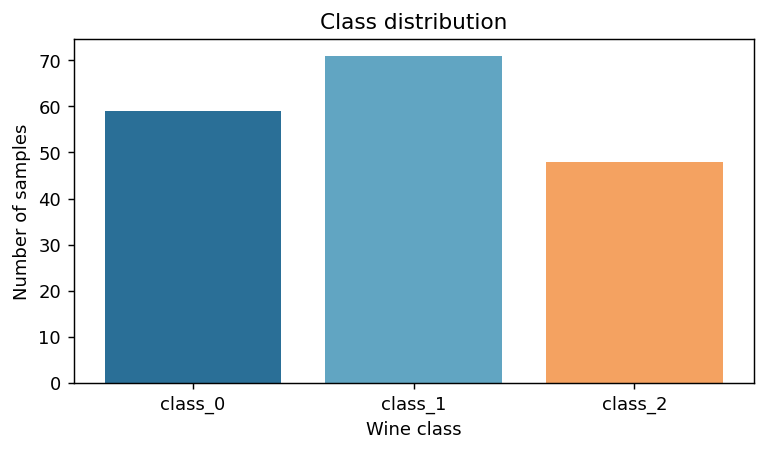

In [2]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y = wine.target.copy()

print(f"样本数：{X.shape[0]}")
print(f"特征数：{X.shape[1]}")
print(f"类别数：{len(wine.target_names)}")
print("类别名称：", list(wine.target_names))
print("\n前5行数据：")
print(X.head().round(2).to_string())

class_counts = y.value_counts().sort_index()
plt.figure(figsize=(6, 3.6))
plt.bar(wine.target_names, class_counts.values, color=["#2A6F97", "#61A5C2", "#F4A261"])
plt.title("Class distribution")
plt.xlabel("Wine class")
plt.ylabel("Number of samples")
plt.tight_layout()

## 3. 保留独立测试集

训练集用于学习和选择模型，测试集只在最后使用。`stratify=y` 使训练集和测试集保持接近原始数据的类别比例。

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"训练集：{X_train.shape[0]} 个样本")
print(f"测试集：{X_test.shape[0]} 个样本")
print("训练集类别比例：")
print(y_train.value_counts(normalize=True).sort_index().round(3).to_string())

训练集：133 个样本
测试集：45 个样本
训练集类别比例：
target
0    0.331
1    0.398
2    0.271


## 4. KNN 怎样完成分类

对于一个新样本，KNN 的基本步骤是：

1. 计算它与训练样本之间的距离；
2. 找到距离最近的 K 个样本；
3. 分类任务采用投票法，票数最多的类别成为预测结果。

KNN 几乎没有传统意义上的参数学习过程。`fit()` 主要保存训练数据，因此它常被称为“懒惰学习”。计算工作主要发生在预测阶段。

### `KNeighborsClassifier` 的主要参数

| 参数 | 作用 | 本案例中的含义 |
|---|---|---|
| `n_neighbors` | 邻居数量 K | K 太小易受噪声影响，太大可能模糊局部结构 |
| `weights` | 邻居投票权重 | `uniform` 等权；`distance` 使近邻权重更大 |
| `metric` | 距离度量 | 默认 `minkowski` |
| `p` | 闵可夫斯基距离的阶数 | `p=1` 为曼哈顿距离，`p=2` 为欧氏距离 |
| `algorithm` | 近邻搜索方法 | `auto`、`brute`、`kd_tree` 或 `ball_tree` |
| `leaf_size` | 树搜索的叶节点规模 | 影响 KD 树/Ball Tree 的速度和内存，不改变距离定义 |

## 5. 为什么 KNN 需要特征缩放

KNN 依赖距离。如果某个特征的数值范围远大于其他特征，它会主导距离计算。我们先查看 Wine 数据中几个特征的范围。

数值范围最大的5个特征：
                   minimum  maximum    range
proline             278.00   1515.0  1237.00
magnesium            70.00    162.0    92.00
alcalinity_of_ash    10.60     30.0    19.40
color_intensity       1.28     13.0    11.72
malic_acid            0.74      5.8     5.06

数值范围最小的5个特征：
                              minimum  maximum  range
total_phenols                    0.98     3.88   2.90
od280/od315_of_diluted_wines     1.27     3.92   2.65
ash                              1.36     3.22   1.86
hue                              0.48     1.71   1.23
nonflavanoid_phenols             0.13     0.63   0.50

5折交叉验证结果：
                model  mean_cv_accuracy    std
         Raw features            0.6615 0.0637
Standardized features            0.9553 0.0431


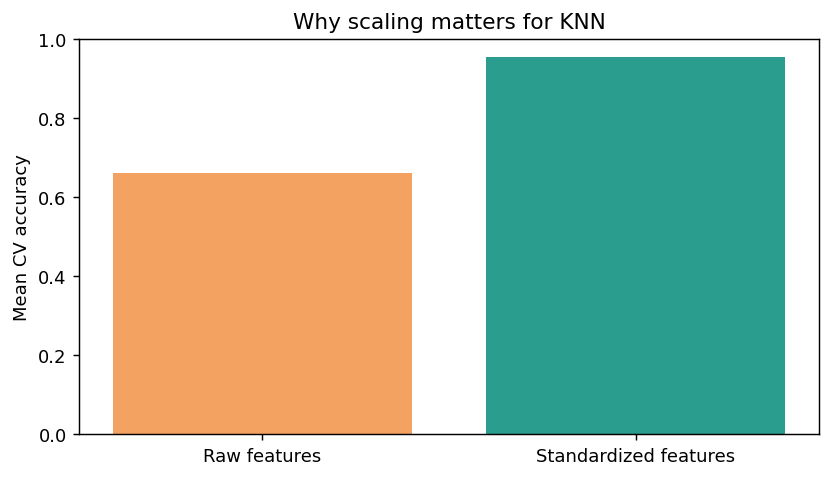

In [4]:
scale_table = pd.DataFrame({
    "minimum": X_train.min(),
    "maximum": X_train.max(),
    "range": X_train.max() - X_train.min(),
}).sort_values("range", ascending=False)

print("数值范围最大的5个特征：")
print(scale_table.head().round(2).to_string())
print("\n数值范围最小的5个特征：")
print(scale_table.tail().round(3).to_string())

raw_model = KNeighborsClassifier(n_neighbors=5)
scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])

raw_scores = cross_val_score(raw_model, X_train, y_train, cv=CV, scoring="accuracy")
scaled_scores = cross_val_score(scaled_model, X_train, y_train, cv=CV, scoring="accuracy")

comparison = pd.DataFrame({
    "model": ["Raw features", "Standardized features"],
    "mean_cv_accuracy": [raw_scores.mean(), scaled_scores.mean()],
    "std": [raw_scores.std(), scaled_scores.std()],
})
print("\n5折交叉验证结果：")
print(comparison.round(4).to_string(index=False))

plt.figure(figsize=(6.5, 3.8))
plt.bar(comparison["model"], comparison["mean_cv_accuracy"], color=["#F4A261", "#2A9D8F"])
plt.ylim(0, 1)
plt.ylabel("Mean CV accuracy")
plt.title("Why scaling matters for KNN")
plt.tight_layout()

**结论：**后续实验把 `StandardScaler` 和 KNN 放在同一个 `Pipeline` 中。这样每一折交叉验证都只用该折的训练部分计算均值和标准差，可以避免数据泄露。

## 6. K 值如何影响结果

为了单独观察 K 的影响，我们固定欧氏距离和等权投票，在训练集上使用 5 折交叉验证测试 K=1～20。

在固定等权投票和欧氏距离时，交叉验证最佳 K：1
对应平均准确率：0.9778


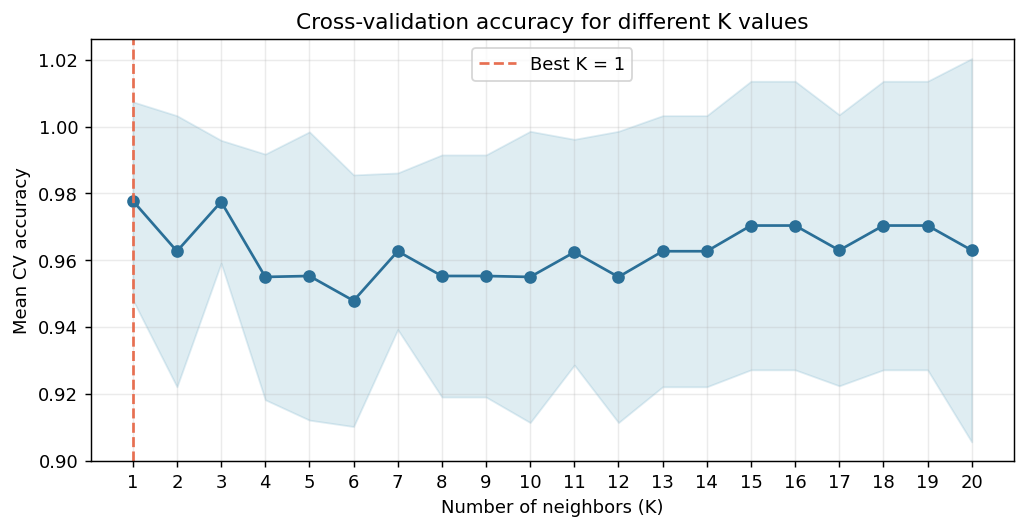

In [5]:
k_values = list(range(1, 21))
k_means = []
k_stds = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="uniform", p=2)),
    ])
    scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="accuracy")
    k_means.append(scores.mean())
    k_stds.append(scores.std())

best_k_in_curve = k_values[int(np.argmax(k_means))]
print(f"在固定等权投票和欧氏距离时，交叉验证最佳 K：{best_k_in_curve}")
print(f"对应平均准确率：{max(k_means):.4f}")

plt.figure(figsize=(8, 4.2))
plt.plot(k_values, k_means, marker="o", color="#2A6F97")
plt.fill_between(
    k_values,
    np.array(k_means) - np.array(k_stds),
    np.array(k_means) + np.array(k_stds),
    color="#61A5C2",
    alpha=0.2,
)
plt.axvline(best_k_in_curve, color="#E76F51", linestyle="--", label=f"Best K = {best_k_in_curve}")
plt.xticks(k_values)
plt.xlabel("Number of neighbors (K)")
plt.ylabel("Mean CV accuracy")
plt.title("Cross-validation accuracy for different K values")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

曲线中的最高点只代表本数据集和本次交叉验证设置下的结果，并不说明存在适用于所有任务的最佳 K。实际项目应在训练数据上通过交叉验证选择 K。

## 7. 等权投票与距离加权

- `weights="uniform"`：每个邻居拥有相同票数；
- `weights="distance"`：距离越近，权重越大。

下面仍使用训练集交叉验证比较两种方式。

In [6]:
weight_results = []
for weight in ["uniform", "distance"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=best_k_in_curve, weights=weight, p=2)),
    ])
    scores = cross_val_score(model, X_train, y_train, cv=CV, scoring="accuracy")
    weight_results.append([weight, scores.mean(), scores.std()])

weight_table = pd.DataFrame(
    weight_results,
    columns=["weights", "mean_cv_accuracy", "std"],
)
print(weight_table.round(4).to_string(index=False))

 weights  mean_cv_accuracy    std
 uniform            0.9778 0.0296
distance            0.9778 0.0296


## 8. 使用 `GridSearchCV` 联合选择参数

现在同时搜索：

- K：1～20；
- 投票方式：等权或距离加权；
- 距离：`p=1` 的曼哈顿距离或 `p=2` 的欧氏距离。

搜索仍只发生在训练集内部，测试集尚未参与。

In [7]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(algorithm="auto")),
])

param_grid = {
    "knn__n_neighbors": list(range(1, 21)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=CV,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=False,
)
grid_search.fit(X_train, y_train)

print("最佳参数：", grid_search.best_params_)
print(f"最佳交叉验证准确率：{grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)
columns = [
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__p",
    "mean_test_score",
    "std_test_score",
]
print("\n排名前5的参数组合：")
print(
    cv_results.sort_values("rank_test_score")[columns]
    .head(5)
    .round(4)
    .to_string(index=False)
)

最佳参数： {'knn__n_neighbors': 4, 'knn__p': 1, 'knn__weights': 'distance'}
最佳交叉验证准确率：0.9926

排名前5的参数组合：
 param_knn__n_neighbors param_knn__weights  param_knn__p  mean_test_score  std_test_score
                      4           distance             1           0.9926          0.0148
                      7           distance             1           0.9926          0.0148
                      6           distance             1           0.9926          0.0148
                      8           distance             1           0.9926          0.0148
                      7            uniform             1           0.9926          0.0148


## 9. 在独立测试集上进行最终评估

`GridSearchCV` 默认会用最佳参数在完整训练集上重新拟合模型。下面第一次使用保留的测试集，评估模型面对未见样本时的表现。

测试集准确率：0.9556

分类报告：
              precision    recall  f1-score   support

     class_0     0.9375    1.0000    0.9677        15
     class_1     1.0000    0.8889    0.9412        18
     class_2     0.9231    1.0000    0.9600        12

    accuracy                         0.9556        45
   macro avg     0.9535    0.9630    0.9563        45
weighted avg     0.9587    0.9556    0.9551        45



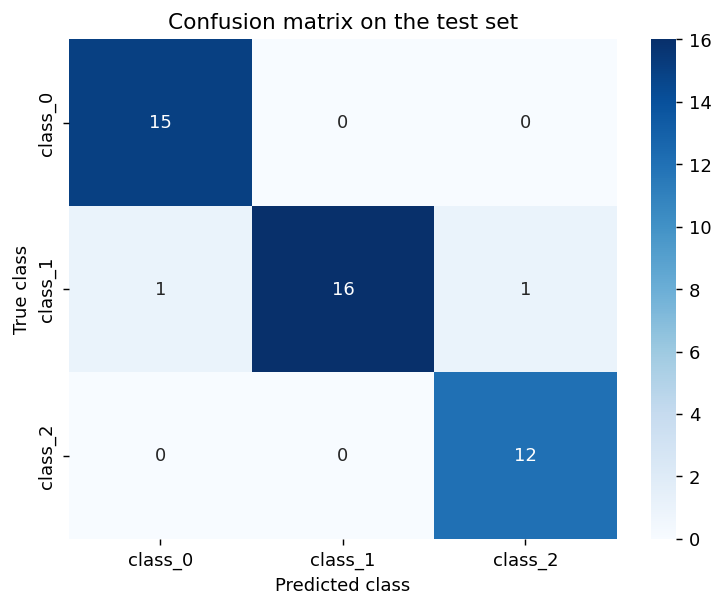

In [8]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"测试集准确率：{test_accuracy:.4f}")
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=wine.target_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names,
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion matrix on the test set")
plt.tight_layout()

## 10. 查看一次预测及其最近邻

`predict()` 给出类别，`predict_proba()` 给出各类别归一化后的投票权重，`kneighbors()` 可以返回最近邻的距离和位置。由于模型在缩放后的空间计算距离，调用 `kneighbors()` 前也要用同一个缩放器转换样本。

In [9]:
sample = X_test.iloc[[0]]
true_class = int(y_test.iloc[0])
predicted_class = int(best_model.predict(sample)[0])
probabilities = best_model.predict_proba(sample)[0]

scaler = best_model.named_steps["scaler"]
knn = best_model.named_steps["knn"]
sample_scaled = scaler.transform(sample)
distances, positions = knn.kneighbors(sample_scaled)
neighbor_labels = y_train.iloc[positions[0]].to_numpy()

print("样本原始索引：", sample.index[0])
print("真实类别：", wine.target_names[true_class])
print("预测类别：", wine.target_names[predicted_class])
print("各类别归一化投票权重：", np.round(probabilities, 4))
print("最近邻距离：", np.round(distances[0], 4))
print("最近邻标签：", neighbor_labels)

样本原始索引： 35
真实类别： class_0
预测类别： class_0
各类别归一化投票权重： [1. 0. 0.]
最近邻距离： [4.1508 4.8485 5.2415 5.4435]
最近邻标签： [0 0 0 0]


## 11. 常用属性和方法

模型训练完成后，可以通过以下接口查看或使用模型：

| 接口 | 含义 |
|---|---|
| `fit(X, y)` | 保存训练样本并建立需要的搜索结构 |
| `predict(X)` | 输出预测类别 |
| `predict_proba(X)` | 输出各类别归一化后的投票权重 |
| `kneighbors(X)` | 返回最近邻的距离和位置 |
| `score(X, y)` | 分类器默认返回准确率 |
| `classes_` | 训练时识别出的类别 |
| `effective_metric_` | 模型实际采用的距离度量 |
| `n_samples_fit_` | 模型保存的训练样本数 |

注意：`predict_proba()` 的输出来自邻居投票权重，不应直接视为经过概率校准的真实概率。

In [10]:
print("classes_：", knn.classes_)
print("effective_metric_：", knn.effective_metric_)
print("n_samples_fit_：", knn.n_samples_fit_)
print("algorithm 参数：", knn.algorithm)

classes_： [0 1 2]
effective_metric_： manhattan
n_samples_fit_： 133
algorithm 参数： auto


## 12. 总结

### KNN 的优点

- 思想直观，容易解释；
- 几乎不需要传统意义上的训练过程；
- 可以同时用于分类和回归。

### KNN 的局限

- 预测时需要进行近邻搜索，数据量大时开销较高；
- 对特征尺度、K 值和距离度量敏感；
- 在高维空间中，距离的区分能力可能下降；
- 对类别不平衡和无关特征也比较敏感。

### 本案例的完整流程

`划分数据 → Pipeline 内标准化 → 训练集交叉验证 → 选择参数 → 独立测试集评估 → 解释一次预测`

这套流程比只调用 `fit()` 和 `predict()` 更重要，因为它保证了实验结果可复现，并减少了数据泄露风险。

## 参考材料

- 课程材料：《第2讲 K近邻法（2025课件）》
- 课程材料：《第2讲 K近邻法（哆啦A梦版）》
- scikit-learn API：`sklearn.neighbors.KNeighborsClassifier`